# 02 - Feature Engineering

Setelah EDA di notebook sebelumnya, langkah selanjutnya adalah menerjemahkan
insight yang sudah ditemukan menjadi fitur yang bisa dipakai model — terutama
fitur rasio finansial yang menurut hasil EDA lebih punya sinyal dibanding nilai
mentahnya sendiri.

Notebook ini akan:
- Membangun fitur-fitur turunan tersebut lewat `src/features.py`
- Mengecek seberapa kuat sinyal masing-masing fitur baru terhadap target, pakai Information Value
- Menyimpan hasilnya ke `data/processed/` supaya bisa langsung dipakai di notebook modeling

Logika feature engineering-nya saya taruh di `src/features.py`, bukan ditulis
langsung di sini — supaya logika yang sama bisa dipakai ulang nanti saat
modeling maupun saat inference, tanpa perlu disalin manual setiap kali.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_raw_tables, build_master_table
from src.features import build_features
from src.config import TARGET_COL, ID_COL, PROCESSED_DATA_DIR

sns.set_style("whitegrid")


## 1. Load & Bangun Fitur

In [2]:
tables = load_raw_tables()
master = build_master_table(tables)
df = build_features(master)

print(f"Shape sebelum feature engineering: {master.shape}")
print(f"Shape setelah feature engineering: {df.shape}")

new_cols = [c for c in df.columns if c not in master.columns]
print(f"\nFitur baru yang ditambahkan ({len(new_cols)}):")
print(new_cols)


Path: D:\credit-risk-scorecard\data\raw\application_train.csv
[INFO] Loaded application_train: (307511, 122)
Path: D:\credit-risk-scorecard\data\raw\application_test.csv
[INFO] Loaded application_test: (48744, 121)
Path: D:\credit-risk-scorecard\data\raw\bureau.csv
[INFO] Loaded bureau: (1716428, 17)
Path: D:\credit-risk-scorecard\data\raw\bureau_balance.csv
[INFO] Loaded bureau_balance: (27299925, 3)
Path: D:\credit-risk-scorecard\data\raw\previous_application.csv
[INFO] Loaded previous_application: (1670214, 37)
Path: D:\credit-risk-scorecard\data\raw\installments_payments.csv
[INFO] Loaded installments_payments: (13605401, 8)
Path: D:\credit-risk-scorecard\data\raw\credit_card_balance.csv
[INFO] Loaded credit_card_balance: (3840312, 23)
Path: D:\credit-risk-scorecard\data\raw\POS_CASH_balance.csv
[INFO] Loaded pos_cash_balance: (10001358, 8)
[INFO] Setelah merge bureau: (307511, 127)
[INFO] Setelah merge previous_application: (307511, 131)
Shape sebelum feature engineering: (307511,

## 2. Validasi Sinyal Fitur Baru — Information Value (IV)

Information Value adalah metric standar industri credit scoring untuk
mengukur seberapa kuat satu fitur memisahkan kelas baik vs default (jatuh tempo).
**Semakin besar nilai IV, semakin kuat fitur tersebut membedakan nasabah
yang default dari yang lunas** — IV tidak menunjukkan arah hubungan
(positif/negatif), hanya seberapa besar *kekuatan pemisahnya*.

Rule of thumb:

| IV          | Interpretasi              |
|-------------|----------------------------|
| < 0.02      | Tidak ada predictive power |
| 0.02 - 0.1  | Lemah                      |
| 0.1 - 0.3   | Sedang                     |
| 0.3 - 0.5   | Kuat                       |
| > 0.5       | Curiga (cek data leakage)  |


In [ ]:
def calculate_iv(df: pd.DataFrame, feature: str, target: str, bins: int = 10) -> float:
    """
    Menghitung Information Value untuk satu fitur numerik kontinu,
    dengan binning kuantil sederhana.

    Catatan: ini implementasi cepat untuk eksplorasi. Untuk scorecard
    final, binning akan dilakukan lebih hati-hati pakai `optbinning`
    di notebook modeling baseline (03).
    """
    temp = df[[feature, target]].dropna().copy()
    if temp[feature].nunique() < 2:
        return np.nan

    try:
        temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    except ValueError:
        return np.nan

    grouped = temp.groupby("bin", observed=True)[target].agg(["count", "sum"])
    # groupby menghasilkan kolom "count" dan "sum", kita ubah namanya menjadi "total" dan "bad"
    grouped.columns = ["total", "bad"]
    grouped["good"] = grouped["total"] - grouped["bad"]

    total_bad = grouped["bad"].sum()
    total_good = grouped["good"].sum()

    grouped["dist_bad"] = grouped["bad"] / total_bad
    grouped["dist_good"] = grouped["good"] / total_good

    # Hindari log(0) dengan epsilon kecil
    eps = 1e-6
    grouped["woe"] = np.log((grouped["dist_good"] + eps) / (grouped["dist_bad"] + eps))
    grouped["iv_contribution"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]

    return grouped["iv_contribution"].sum()


iv_results = {}
for col in new_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        iv_results[col] = calculate_iv(df, col, TARGET_COL)

iv_df = pd.Series(iv_results).sort_values(ascending=False).to_frame("IV")
iv_df


,IV
CREDIT_TO_ANNUITY_RATIO,0.143626
EMPLOYMENT_LENGTH_YEARS,0.092528
AGE_YEARS,0.084175
EMPLOYMENT_TO_AGE_RATIO,0.067883
DEBT_TO_INCOME_RATIO,0.010383
BUREAU_CREDIT_TO_INCOME_RATIO,0.006709
ANNUITY_TO_INCOME_RATIO,0.005894
IS_EMPLOYMENT_ANOMALY,0.000000
HAS_NO_BUREAU_HISTORY,0.000000
OWN_CAR_AGE_MISSING,0.000000


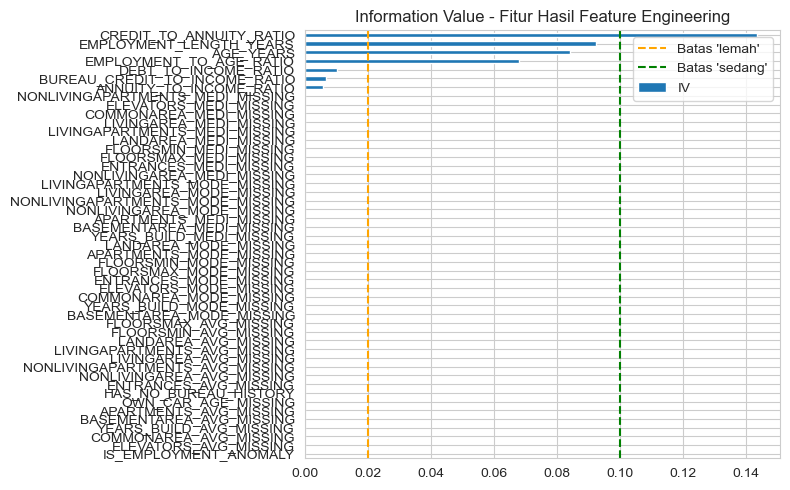

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
iv_df["IV"].sort_values().plot(kind="barh", ax=ax)
ax.axvline(0.02, color="orange", linestyle="--", label="Batas 'lemah'")
ax.axvline(0.1, color="green", linestyle="--", label="Batas 'sedang'")
ax.set_title("Information Value - Fitur Hasil Feature Engineering")
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** *(isi setelah melihat hasil IV — fitur mana yang punya predictive
power kuat/sedang, dan apakah ada fitur yang ternyata lemah sehingga
dipertimbangkan untuk tidak dipakai di modeling? Tulis juga jika ada fitur
dengan IV mencurigakan tinggi, perlu dicek potensi data leakage.)*

## 3. Cek Korelasi Antar Fitur Baru

Memastikan tidak ada multikolinearitas ekstrem antar fitur turunan
(misal `DEBT_TO_INCOME_RATIO` vs `ANNUITY_TO_INCOME_RATIO` bisa jadi
berkorelasi tinggi karena sama-sama melibatkan income).

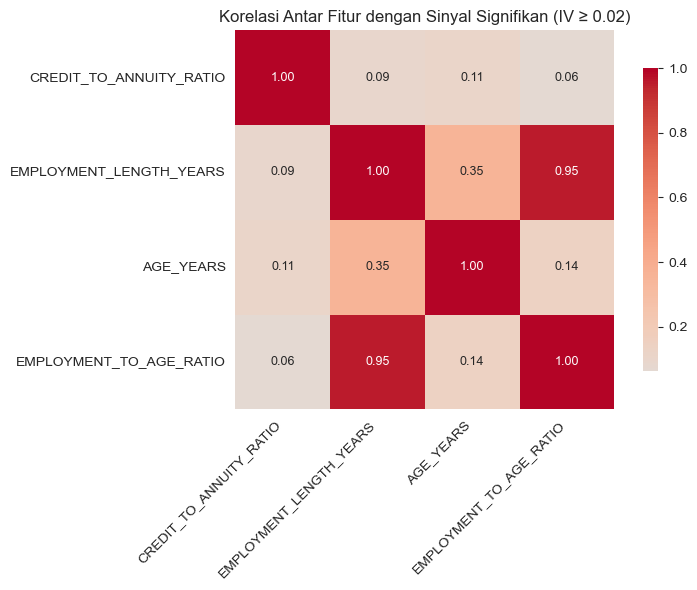

In [12]:
# Hanya cek korelasi untuk fitur yang punya IV >= 0.02 (lemah ke atas)
# -- fitur ber-IV nol percuma ditampilkan di heatmap korelasi
meaningful_features = iv_df[iv_df["IV"] >= 0.02].index.tolist()
meaningful_features = [c for c in meaningful_features if c in df.columns]

corr = df[meaningful_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    ax=ax, annot_kws={"size": 9}, square=True,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Korelasi Antar Fitur dengan Sinyal Signifikan (IV \u2265 0.02)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Insight:** Setelah difilter ke fitur dengan IV ≥ 0.02, korelasi antar
fitur secara umum rendah hingga sedang — kecuali satu pasangan yang
sangat tinggi: `EMPLOYMENT_LENGTH_YEARS` dan `EMPLOYMENT_TO_AGE_RATIO`
(korelasi 0.95).

Ini sebenarnya **wajar secara matematis**, bukan temuan baru — karena
`EMPLOYMENT_TO_AGE_RATIO` dihitung langsung dari `EMPLOYMENT_LENGTH_YEARS`
dibagi `AGE_YEARS` (lihat `src/features.py::add_employment_features()`),
sehingga kedua fitur ini secara desain saling bergantung erat.

**Implikasi:** membawa kedua fitur ini bersamaan ke model linear
(Logistic Regression) berisiko menyebabkan multikolinearitas, yang bisa
membuat koefisien model jadi tidak stabil/sulit diinterpretasi secara
individual. Untuk model berbasis tree (LightGBM) hal ini kurang
bermasalah, tapi untuk konsistensi dan interpretability, salah satu dari
dua fitur ini akan dipertimbangkan untuk di-drop saat modeling baseline
— `EMPLOYMENT_TO_AGE_RATIO` lebih mungkin dipertahankan karena secara
konsep menangkap proporsi (stabilitas relatif terhadap usia), bukan
sekadar durasi absolut.

Fitur lain (`CREDIT_TO_ANNUITY_RATIO`, `AGE_YEARS`) tidak menunjukkan
korelasi tinggi dengan fitur lainnya, sehingga aman dibawa bersamaan ke
model tanpa risiko redundansi informasi.

## 4. Simpan Master Table

In [13]:
# Drop fitur yang terbukti tidak berguna (IV = 0) berdasarkan analisis di atas
zero_iv_features = iv_df[iv_df["IV"] == 0].index.tolist()
zero_iv_features = [c for c in zero_iv_features if c in df.columns]

# Drop salah satu dari pasangan fitur yang sangat berkorelasi (0.95)
# -- EMPLOYMENT_TO_AGE_RATIO dipertahankan karena menangkap proporsi,
# bukan sekadar durasi absolut (lihat insight korelasi di atas)
redundant_features = ["EMPLOYMENT_LENGTH_YEARS"]

features_to_drop = zero_iv_features + redundant_features
df_final = df.drop(columns=features_to_drop)

print(f"Fitur yang di-drop: {len(features_to_drop)}")
print(f"Shape sebelum drop: {df.shape}")
print(f"Shape setelah drop: {df_final.shape}")

output_path = PROCESSED_DATA_DIR / "master_table.parquet"
df_final.to_parquet(output_path, index=False)
print(f"\nMaster table disimpan ke: {output_path}")
print(f"Shape final: {df_final.shape}")

Fitur yang di-drop: 43
Shape sebelum drop: (307511, 180)
Shape setelah drop: (307511, 137)

Master table disimpan ke: D:\credit-risk-scorecard\data\processed\master_table.parquet
Shape final: (307511, 137)


## 5. Ringkasan & Langkah Selanjutnya

Dari 49 fitur turunan yang dibangun lewat `src/features.py`, hanya
sebagian kecil yang terbukti punya sinyal terhadap target:

- **`CREDIT_TO_ANNUITY_RATIO`** (IV = 0.144) — fitur dengan sinyal
  terkuat dari seluruh proses feature engineering ini, mengonfirmasi
  hipotesis bahwa rasio antar variabel finansial lebih predictive
  dibanding nilai mentahnya sendiri (sesuai temuan EDA sebelumnya, di
  mana `AMT_INCOME_TOTAL` dan `AMT_CREDIT` mentah tidak menunjukkan
  separasi visual yang jelas).
- **`AGE_YEARS`** (IV = 0.084) — mengonfirmasi secara kuantitatif pola
  yang sudah terlihat di EDA, di mana usia adalah satu-satunya fitur
  mentah dengan separasi visual jelas antar kelas target.
- **`EMPLOYMENT_TO_AGE_RATIO`** (IV = 0.068) dan **`EMPLOYMENT_LENGTH_YEARS`**
  (IV = 0.093) juga berguna, namun keduanya berkorelasi sangat tinggi
  (0.95) karena saling diturunkan satu sama lain — `EMPLOYMENT_LENGTH_YEARS`
  di-drop untuk menghindari redundansi, sementara `EMPLOYMENT_TO_AGE_RATIO`
  dipertahankan karena menangkap proporsi (stabilitas kerja relatif
  terhadap usia), bukan sekadar durasi absolut.
- **Seluruh 41 flag `*_MISSING` untuk kolom properti** (`COMMONAREA`,
  `LIVINGAPARTMENTS`, dst) ternyata IV = 0 — hipotesis bahwa status
  "missing" pada kolom-kolom ini informatif terhadap risiko default
  **tidak terbukti secara empiris**, meskipun secara konsep make sense.
  Kolom-kolom ini di-drop dari master table final.
- Fitur rasio sederhana seperti `DEBT_TO_INCOME_RATIO` dan
  `ANNUITY_TO_INCOME_RATIO` punya IV sangat rendah (0.01 dan 0.006) —
  lebih lemah dari perkiraan awal, kemungkinan karena `AMT_INCOME_TOTAL`
  sendiri sudah terbukti kurang predictive di EDA, sehingga rasio apa
  pun yang melibatkan variabel ini ikut terbawa lemah.

**Keputusan akhir:** master table final menyimpan seluruh fitur asli
ditambah fitur turunan yang punya IV > 0, dikurangi satu fitur redundan
(`EMPLOYMENT_LENGTH_YEARS`). Fitur dengan IV = 0 di-drop untuk menjaga
dimensi data tetap relevan, terutama karena WOE binning di notebook
modeling baseline akan dilakukan untuk seluruh fitur numerik secara
otomatis — membawa fitur yang sudah terbukti tidak berguna hanya akan
menambah waktu komputasi tanpa manfaat.